importing stuff

In [ ]:
#churn means people who left hte company

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

loading data and peeking into data


In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

In [5]:
df.head(5)
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.shape

(7043, 21)

In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [27]:
#here total charges is in obj i need to convert into float
print(type(df['TotalCharges'][0]))
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce') #If 'coerce', then invalid parsing will be set as NaN.
print(df['TotalCharges'].dtype)
df['TotalCharges'].isnull().sum()

<class 'numpy.float64'>
float64


np.int64(11)

In [30]:
df.dropna(subset=['TotalCharges'], inplace=True)
df.shape

(7032, 21)

In [31]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [39]:
print(df['Churn'].value_counts())
print((df["Churn"].value_counts(normalize=True)*100))

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [53]:
df.shape

(7032, 20)

In [54]:
df.duplicated().sum()

np.int64(22)

In [55]:
df.drop_duplicates(inplace=True)

In [56]:
df.duplicated().sum()

np.int64(0)

EDA

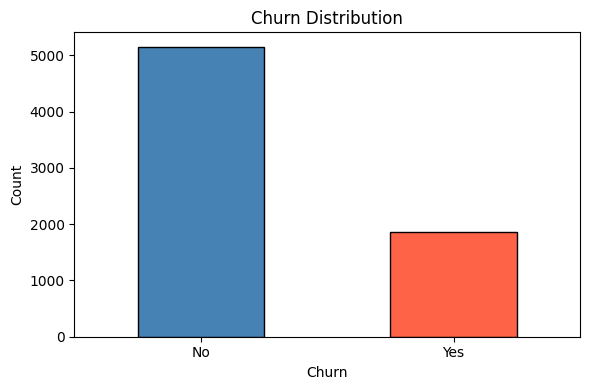

Churn
No     5153
Yes    1857
Name: count, dtype: int64

Churn Rate: 26.49%


In [57]:
plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['Churn'].value_counts())
print(f"\nChurn Rate: {round(df['Churn'].value_counts(normalize=True)['Yes']*100,2)}%")

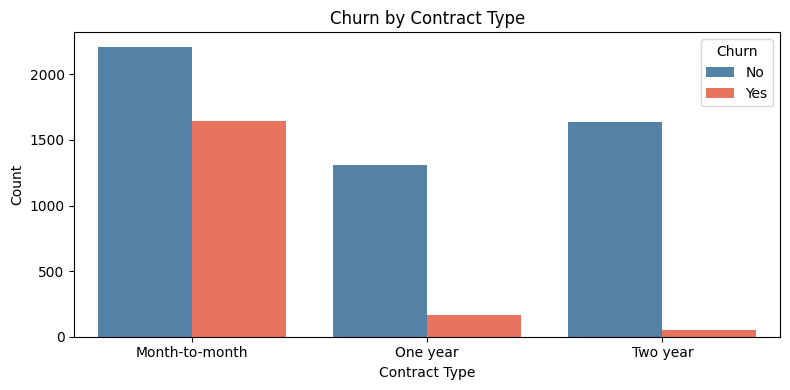

In [58]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['steelblue','tomato'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_205/274092863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['steelblue','tomato'])


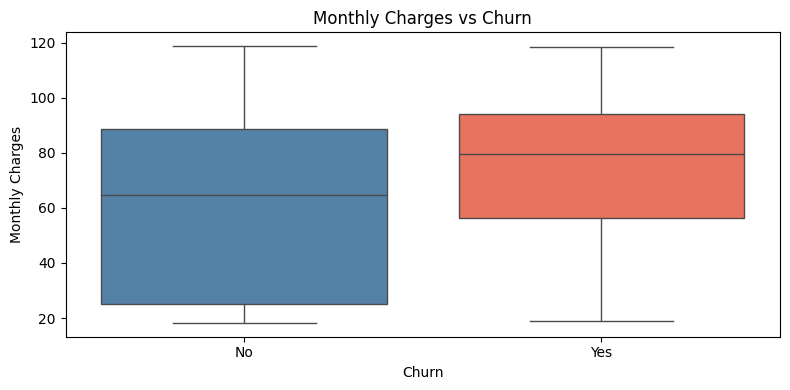

In [59]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['steelblue','tomato'])
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

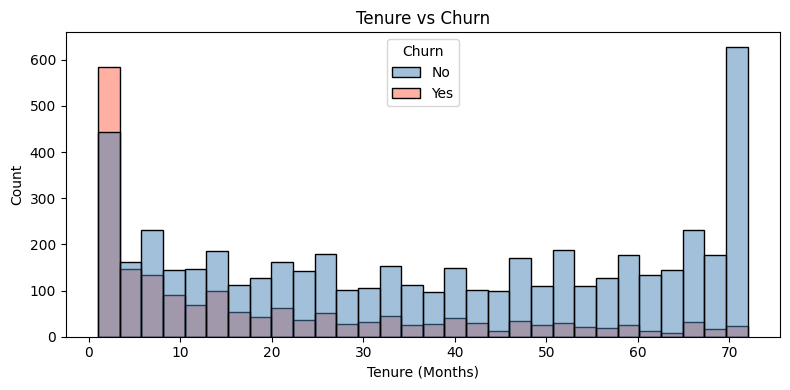

In [60]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue','tomato'])
plt.title('Tenure vs Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

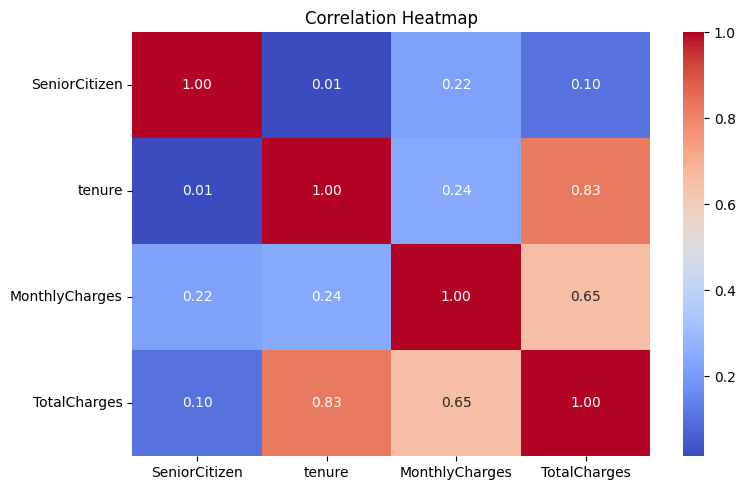

In [61]:
plt.figure(figsize=(8,5))
numeric_df = df.select_dtypes(include=['float64','int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

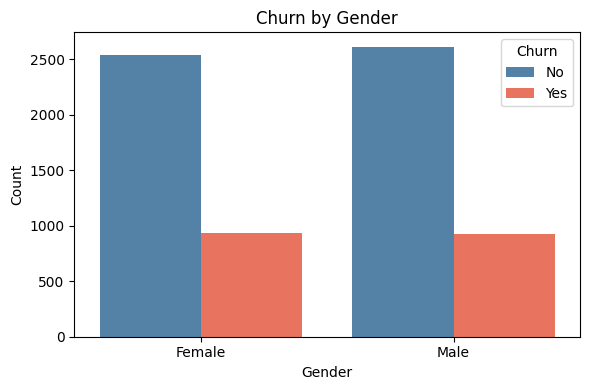

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender', hue='Churn', palette=['steelblue','tomato'])
plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

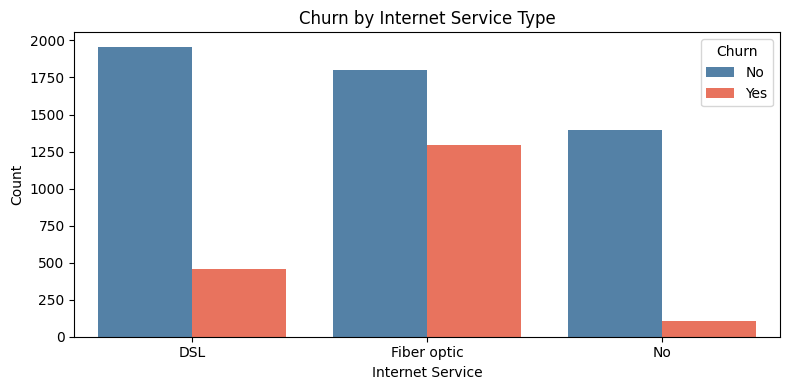

In [63]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['steelblue','tomato'])
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

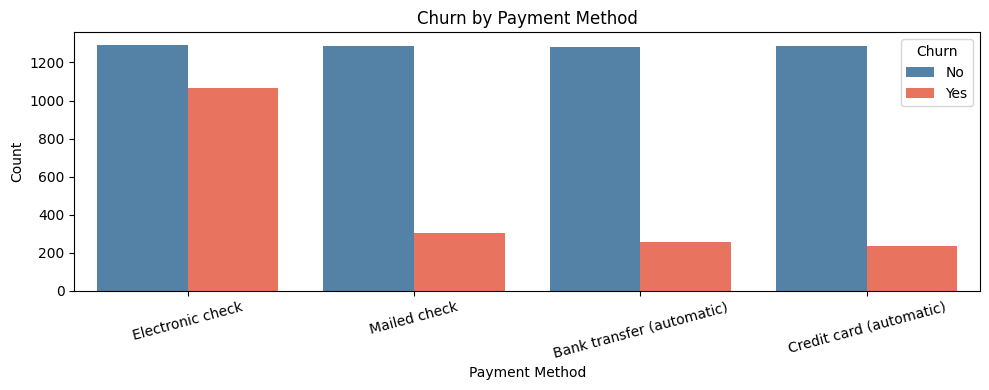

In [64]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette=['steelblue','tomato'])
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

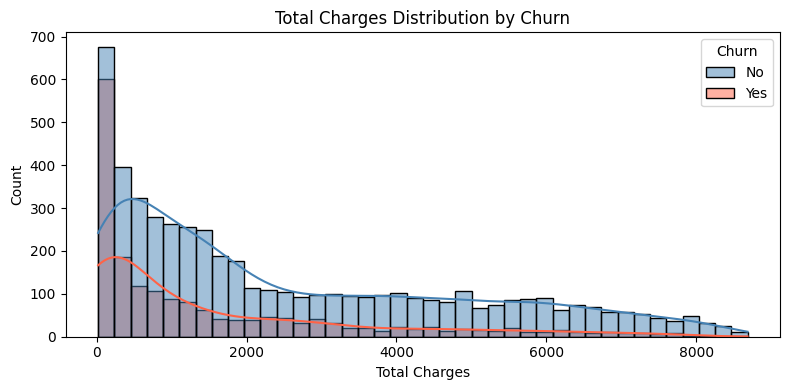

In [65]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='TotalCharges', hue='Churn', bins=40,
             palette=['steelblue','tomato'], kde=True)
plt.title('Total Charges Distribution by Churn')
plt.xlabel('Total Charges')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

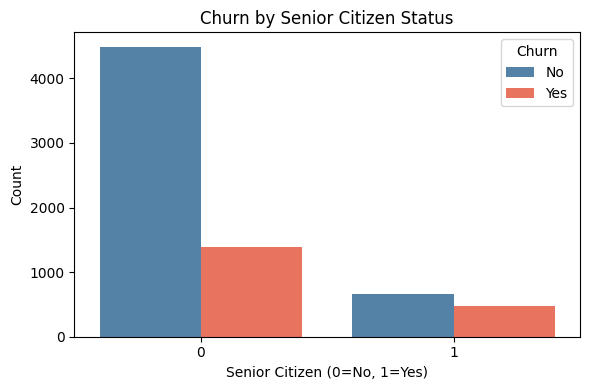

In [66]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette=['steelblue','tomato'])
plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

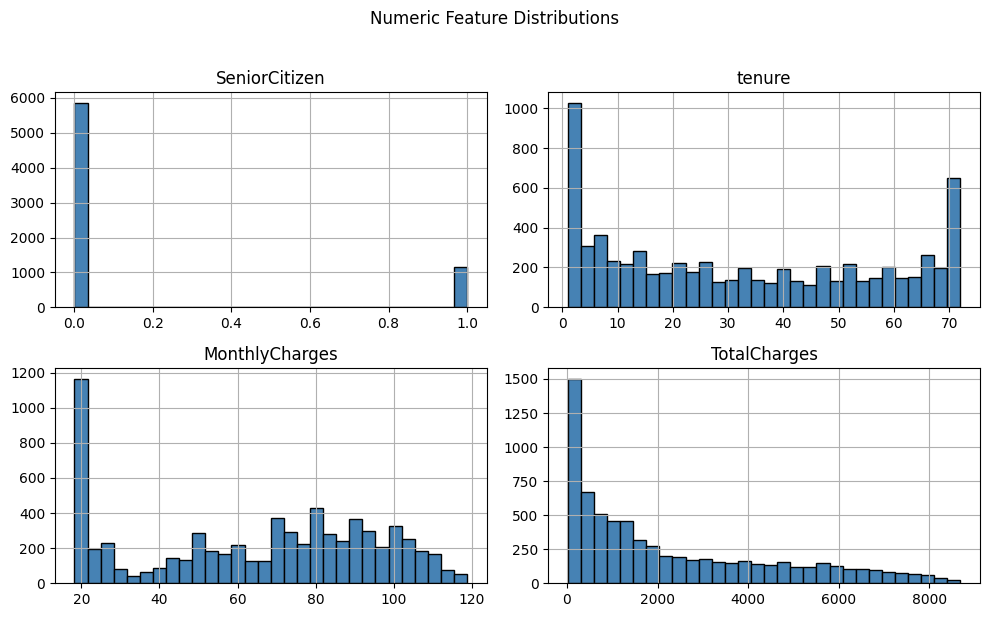

In [67]:
df.select_dtypes(include=['float64','int64']).hist(
    bins=30, figsize=(10,6), color='steelblue', edgecolor='black')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

PRE-PROCESSING


In [71]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Series([], Name: count, dtype: int64)


In [72]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"📋 Categorical Columns ({len(cat_cols)}):")
print(cat_cols)

📋 Categorical Columns (15):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])
print(df[num_cols].describe().round(2))

        tenure  MonthlyCharges  TotalCharges
count  7010.00         7010.00       7010.00
mean     -0.00           -0.00         -0.00
std       1.00            1.00          1.00
min      -1.29           -1.55         -1.00
25%      -0.96           -0.97         -0.83
50%      -0.14            0.18         -0.39
75%       0.96            0.83          0.67
max       1.61            1.79          2.82


In [78]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (7010, 30)
y shape: (7010,)


In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nTrain churn rate: {round(y_train.mean()*100,2)}%")
print(f"Test churn rate:  {round(y_test.mean()*100,2)}%")

ValueError: Input y contains NaN.

In [83]:
print(f"NaN in y: {y.isnull().sum()}")
print(f"NaN in X: {X.isnull().sum().sum()}")

# Check Churn column unique values
print("\nChurn unique values:", df['Churn'].unique())

NaN in y: 7010
NaN in X: 0

Churn unique values: [nan]


In [84]:
df.dropna(subset=['Churn'], inplace=True)

# Recreate X and y after fix
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f" New shape: {df.shape}")
print(f"NaN in y: {y.isnull().sum()}")

 New shape: (0, 31)
NaN in y: 0


In [87]:
# ── FULL CLEAN PIPELINE ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Load
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# 2. Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# 3. Drop customerID & duplicates
df.drop('customerID', axis=1, inplace=True)
df.drop_duplicates(inplace=True)

# 4. Encode target BEFORE get_dummies
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 5. One hot encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 6. Scale numeric columns
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])

# 7. Split X and y
X = df.drop('Churn', axis=1)
y = df['Churn']

# 8. Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f" X_train: {X_train.shape}")
print(f" X_test:  {X_test.shape}")
print(f" Train churn rate: {round(y_train.mean()*100,2)}%")
print(f" Test churn rate:  {round(y_test.mean()*100,2)}%")

 X_train: (5608, 30)
 X_test:  (1402, 30)
 Train churn rate: 26.5%
 Test churn rate:  26.46%


In [88]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [89]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print(" Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\n Classification Report:")
print(classification_report(y_test, y_pred))

 Accuracy: 79.03 %

 Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1031
           1       0.64      0.48      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.70      1402
weighted avg       0.78      0.79      0.78      1402



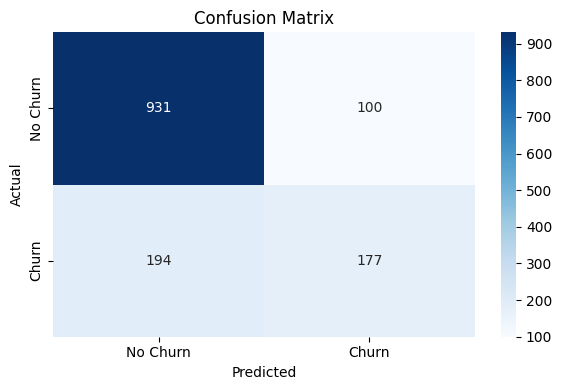

In [90]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

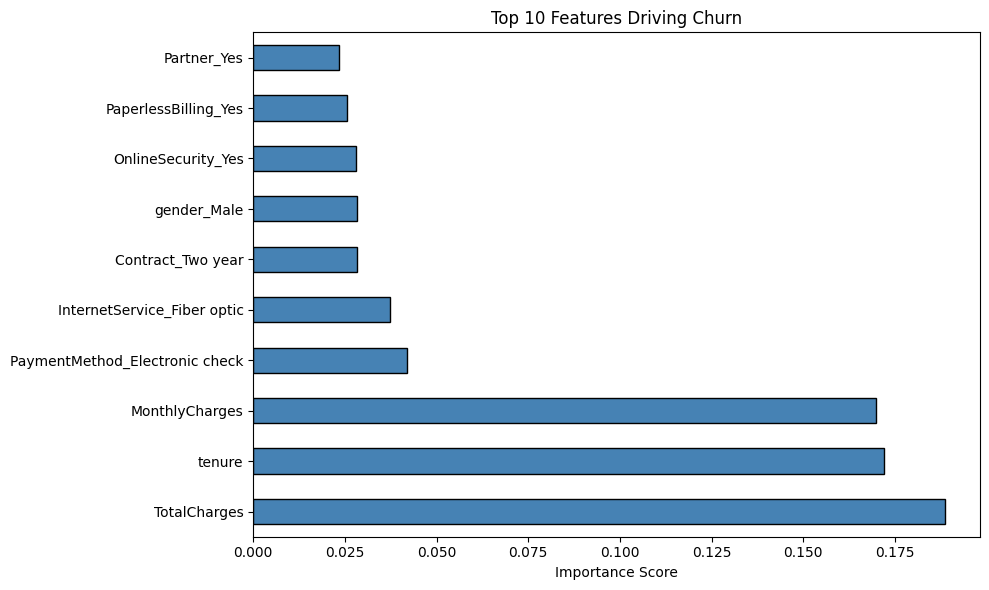


 Top 10 Features:
TotalCharges                      0.188783
tenure                            0.172156
MonthlyCharges                    0.169818
PaymentMethod_Electronic check    0.041827
InternetService_Fiber optic       0.037376
Contract_Two year                 0.028408
gender_Male                       0.028265
OnlineSecurity_Yes                0.028149
PaperlessBilling_Yes              0.025650
Partner_Yes                       0.023338
dtype: float64


In [92]:
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
importances.nlargest(10).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Features Driving Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n Top 10 Features:")
print(importances.nlargest(10))

✅ Random Forest: 79.03%
✅ Logistic Regression: 80.74%
✅ Gradient Boosting: 80.39%


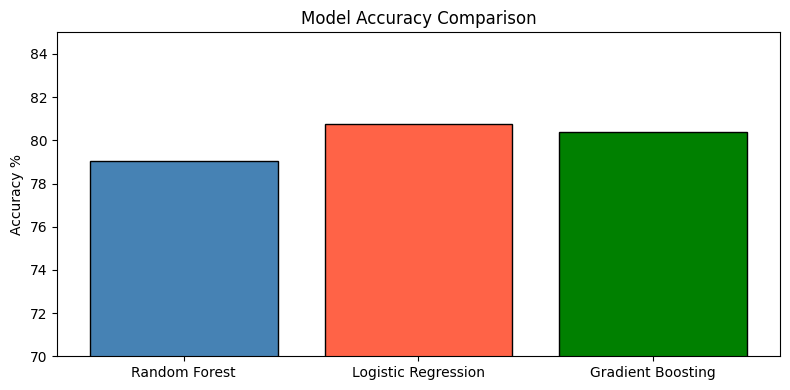

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

models = {
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    acc = round(accuracy_score(y_test, m.predict(X_test))*100, 2)
    results[name] = acc
    print(f"✅ {name}: {acc}%")

# Plot comparison
plt.figure(figsize=(8,4))
plt.bar(results.keys(), results.values(), color=['steelblue','tomato','green'], edgecolor='black')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy %')
plt.ylim(70, 85)
plt.tight_layout()
plt.show()